# Визуальная одометрия на аэроснимках ALTO

**Задача.** Построить систему оценки собственного движения (Visual Odometry)
по надирной аэросъёмке, реализовать и сравнить три подхода к сопоставлению
кадров, проанализировать устойчивость точек, качество сопоставления,
геометрию, накопление ошибки и нагрузку на устройство инференса.

**Данные.** ALTO (GPR-Competition 2022) — надирная съёмка с вертолёта над Огайо.
Сплиты Train (10 436 кадров, 28.5 км), Val (1 684 кадра, 4.6 км),
Test (4 209 кадров, без телеметрии).

---

## Краткая сводка результатов

| Что выяснилось | Где |
|---|---|
| Выбор фронтенда влияет на точность слабее выбора геометрической модели (5.6–52 % против 139–157 %) | §4, §7 |
| Модель подобия на наклонной сцене **систематически выдумывает поворот**; 56 % смещения объясняется креном аналитически при наклоне регрессии 1.03 | §6.3 |
| Доля инлаеров **не отражает качество**: растёт с порогом в 2.6 раза, ошибка траектории при этом меняется немонотонно и лишь на 30 % | §5.2 |
| Универсально лучшего бэкенда нет: ранг переворачивается между сплитами в зависимости от насыщенности сцены точками | §7.2 |
| SuperPoint+LightGlue не окупается: ниже повторяемость, в 2.6 раза медленнее, 577 МБ VRAM | §4.2, §8 |
| Фокусное расстояние по плоской надирной сцене **принципиально неопределимо** | §2.3 |

## Структура

| § | Содержание | Пункт задания |
|---|---|---|
| 1 | Данные, сплиты, ограничения раздачи | — |
| 2 | Калибровка: GSD, матрица камеры, выбор базы | — |
| 3 | Архитектура системы и три подхода | 1 a/b/c |
| 4 | Устойчивость ключевых точек | (a) |
| 5 | Качество сопоставления, RANSAC | (b) |
| 6 | Геометрический анализ | (c) |
| 7 | Накопление ошибки, дрейф | (d) |
| 8 | Нагрузка на устройство инференса | (e) |
| 9 | Выводы и ограничения | — |

## 0. Окружение

Модули вынесены в отдельные файлы, чтобы отчёт оставался читаемым:

| файл | содержание |
|---|---|
| `alto_data.py` | загрузка сплитов, гео-преобразования, кэш кадров |
| `vo_core.py` | фронтенды, геометрические бэкенды, интегратор, метрики |
| `learned_frontends.py` | SuperPoint+LightGlue и запасной DISK+LightGlue |
| `profiling.py` | замеры latency, RSS, VRAM |

```bash
pip install "opencv-contrib-python==4.13.0.92" numpy scipy pandas matplotlib tqdm pyproj psutil pynvml
pip install torch --index-url https://download.pytorch.org/whl/cu124
pip install git+https://github.com/cvg/LightGlue.git
```

⚠️ `opencv-contrib-python` строго 4.x: в OpenCV 5.0 отсутствуют `AKAZE_create`
и `logPolar`, которые здесь используются. Пакеты `opencv-python`,
`opencv-contrib-python` и `opencv-python-headless` ставят один и тот же модуль
`cv2` и молча перетирают друг друга — при конфликте снимать все три и ставить
одну сборку.

In [1]:
import sys, time, warnings
from pathlib import Path

import cv2, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from scipy.spatial import cKDTree

sys.path.insert(0, str(Path.cwd()))
import alto_data as ad, vo_core as vc, profiling as pf
from alto_data import AltoSplit, similarity_between, wrap_pi

warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams.update({"figure.figsize": (11, 4), "figure.dpi": 110, "font.size": 9})
pd.set_option("display.width", 240)
np.set_printoptions(precision=4, suppress=True)

# --- пути и режим ---------------------------------------------------------
ROOT      = Path("/mnt/d/deepsound")        # D:\deepsound в терминах WSL
CACHE_DIR = Path.home() / "alto_cache"      # ОБЯЗАТЕЛЬНО на ext4, не на /mnt/d
LOGS      = Path("logs")

# False -- подхватить готовые CSV из logs/ (быстро, для правки текста)
# True  -- пересчитать всё с нуля (~40-60 мин)
RECOMPUTE = False

def cached(name, fn, index_col=None):
    """Считает fn() или читает готовый CSV. Возвращает DataFrame."""
    p = LOGS / name
    if not RECOMPUTE and p.exists():
        print(f"[cache] {name}")
        return pd.read_csv(p, index_col=index_col)
    LOGS.mkdir(exist_ok=True)
    df = fn()
    df.to_csv(p, index=index_col is not None)
    return df

print("OpenCV", cv2.__version__)
assert cv2.__version__.startswith("4."), "нужен OpenCV 4.x (см. выше)"

/root/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


OpenCV 4.13.0


## 1. Данные

### 1.1 Что представляет собой раздача

Это **не полный ALTO**, а подвыборка, подготовленная под соревнование
GPR-Competition 2022 по распознаванию мест (Visual Place Recognition).
Отсюда три особенности, определившие весь дальнейший дизайн:

1. **Кадры 500×500 RGB** получены из исходных 1600×1200 неизвестным сочетанием
   кропа и ресайза. Матрица камеры в раздаче отсутствует.
2. **Лазерного высотомера нет.** Поле `altitude` — высота над эллипсоидом WGS84,
   а не над землёй, поэтому метрический масштаб напрямую из телеметрии не берётся.
3. **Сплит Test перемешан**, содержит вперемешку query- и reference-кадры
   и не имеет телеметрии — для одометрии непригоден в принципе.

Позиции даны сразу в UTM 17N (метры), что избавляет от преобразований ECEF.
Ориентация — кватернион (scalar-last) относительно ECEF.

### 1.2 Схема использования сплитов

Обучения в задаче нет (LightGlue используется предобученным), поэтому сплиты
переосмыслены под задачу оценки:

| сплит | роль | обоснование |
|---|---|---|
| **Val** (4.6 км) | подбор гиперпараметров | короткий, быстро прогоняется |
| **Train** (28.5 км) | итоговые числа, анализ дрейфа | длинный ⇒ виден рост ошибки |
| **Test** (4 209 кадров) | — | без GT непригоден |

Гиперпараметры (порог RANSAC, stride, `k1`, число точек) подбирались на Val,
итоговые метрики считаны на Train. Обе таблицы приводятся: расхождение между
ними само по себе является результатом (§7.2).

In [2]:
train = AltoSplit(ROOT, "Train", cache_dir=CACHE_DIR)
val   = AltoSplit(ROOT, "Val",   cache_dir=CACHE_DIR)

# Кэш кадров в один .npy на ext4. Чтение мелких png через /mnt/d (drvfs)
# даёт ~40 кадров/с, из memmap -- на три порядка быстрее.
train.build_gray_cache(); val.build_gray_cache()
print(train); print(val)

<AltoSplit Train: 10436 кадров, 28.5 км>
<AltoSplit Val: 1684 кадров, 4.6 км>


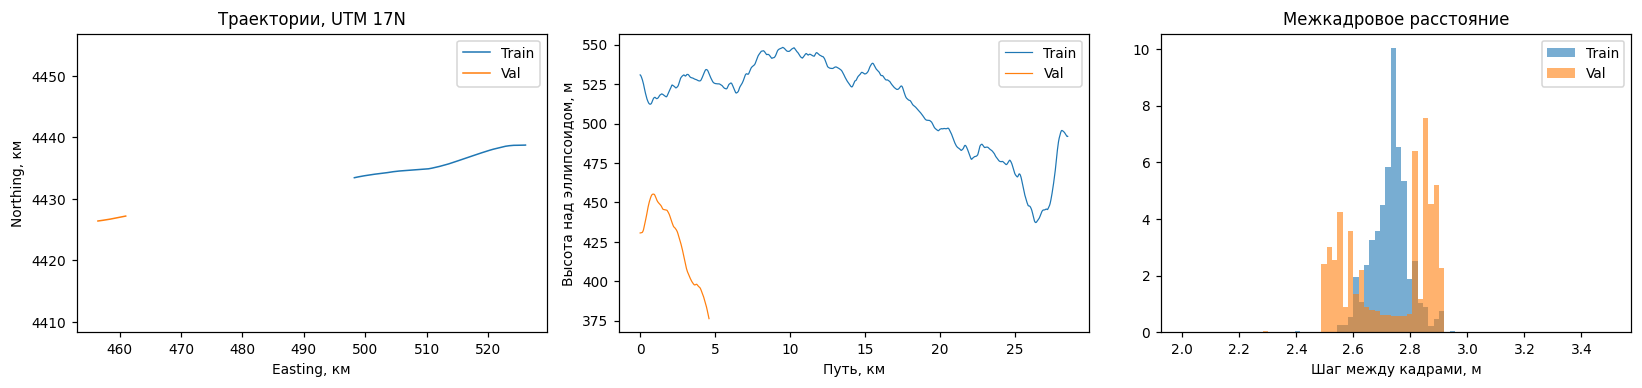

Train  N= 10436  путь= 28.51 км  шаг: медиана 2.74 м, p99 2.90, CV 2.4 %  разрывов: 0
Val    N=  1684  путь=  4.59 км  шаг: медиана 2.81 м, p99 2.92, CV 5.3 %  разрывов: 0


In [3]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
for s, col in [(train, "tab:blue"), (val, "tab:orange")]:
    ax[0].plot(s.xy[:, 0] / 1000, s.xy[:, 1] / 1000, lw=1, color=col, label=s.name)
    ax[1].plot(s.arc_length_m() / 1000, s.alt, lw=.8, color=col, label=s.name)
    ax[2].hist(s.step_m(), bins=80, range=(2, 3.5), alpha=.6, density=True, label=s.name)
ax[0].set_xlabel("Easting, км"); ax[0].set_ylabel("Northing, км"); ax[0].axis("equal")
ax[0].set_title("Траектории, UTM 17N"); ax[0].legend()
ax[1].set_xlabel("Путь, км"); ax[1].set_ylabel("Высота над эллипсоидом, м"); ax[1].legend()
ax[2].set_xlabel("Шаг между кадрами, м"); ax[2].set_title("Межкадровое расстояние"); ax[2].legend()
plt.tight_layout(); plt.show()

for s in (train, val):
    st = s.step_m()
    print(f"{s.name:6s} N={len(s):6d}  путь={s.path_length_m()/1000:6.2f} км  "
          f"шаг: медиана {np.median(st):.2f} м, p99 {np.percentile(st,99):.2f}, "
          f"CV {100*st.std()/st.mean():.1f} %  разрывов: {len(s.segments())-1}")

> **Важное наблюдение.** Шаг между кадрами — 2.74 м с коэффициентом вариации
> около 2 %. Такой равномерности при съёмке 20 Гц с вертолёта не бывает:
> скорость менялась бы. Значит последовательность **передискретизирована
> по пространству**, а не по времени.
>
> Два следствия: (1) частота кадров не привязана к реальному времени, поэтому
> латентность корректно приводить в мс/кадр, а не обсуждать «реальное время»;
> (2) постоянная длина шага — почти точная модель движения, что используется
> в §3.4 и оговаривается как свойство этого датасета.

## 2. Калибровка

### 2.1 Ground Sample Distance

Матрица камеры неизвестна, но масштаб измеряется прямо из данных.
Для надирной камеры пиксельное смещение между кадрами связано с метрическим как

$$\Delta d_{\text{м}} = \text{GSD}\cdot\lVert\Delta \mathbf{p}_{\text{px}}\rVert$$

Смещение оценивается 2D-подобием. **Тонкость:** свободный член аффинной
матрицы $M_{:,2}$ задаёт смещение относительно пикселя $(0,0)$ и содержит
вклад поворота вокруг угла кадра. Мерить надо относительно главной точки:

$$\Delta\mathbf{p} = M_{:,2} - (I - A)\,\mathbf{c}$$

где $A$ — линейная часть, $\mathbf{c}$ — главная точка. Пренебрежение этой
поправкой занижает GSD на 6–7 % (при повороте 2° это 4 px на кадр).

In [4]:
sift = vc.DescriptorFrontEnd("sift", n_features=2000)
STRIDE = 20

def measure_shift(split, k, n=300, seed=0, pp=(250.0, 250.0)):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(split) - k, size=min(n, len(split) - k), replace=False)
    rows = []
    for i in tqdm(idx, leave=False, desc=f"stride={k}"):
        i = int(i)
        m = sift(split.gray(i), split.gray(i + k))
        if m.n < 30:
            continue
        M, inl = cv2.estimateAffinePartial2D(m.pts0, m.pts1, method=cv2.RANSAC,
                                             ransacReprojThreshold=3.0, maxIters=10000)
        if M is None or inl is None or inl.sum() < 20:
            continue
        A = M[:2, :2]
        d = M[:2, 2] - (np.eye(2) - A) @ np.asarray(pp)      # поправка на главную точку
        rows.append(dict(i=i, px=float(np.hypot(*d)),
                         gt_m=float(np.linalg.norm(split.xy[i + k] - split.xy[i]))))
    return pd.DataFrame(rows)

cal = cached("rep_gsd.csv", lambda: pd.concat(
    [measure_shift(train, k, seed=k) for k in (10, 20, 40)], ignore_index=True))

GSD = float((cal.px * cal.gt_m).sum() / (cal.px ** 2).sum())
F_EFF = 3.5 / 0.0045 * 500 / 1200          # кроп 1200x1200 из 1600x1200, ресайз в 500
AGL = GSD * F_EFF
K = np.array([[F_EFF, 0, 250.0], [0, F_EFF, 250.0], [0, 0, 1.0]])

resid = cal.gt_m - GSD * cal.px
print(f"GSD   = {GSD:.4f} м/px   (невязка std {resid.std():.2f} м, {100*resid.std()/cal.gt_m.mean():.1f} %)")
print(f"f_eff = {F_EFF:.1f} px    FOV = {2*np.degrees(np.arctan(250/F_EFF)):.1f}°")
print(f"AGL   = {AGL:.1f} м       захват кадра {GSD*500:.0f} × {GSD*500:.0f} м")
print("K =\n", K)

GSD   = 0.6010 м/px   (невязка std 12.56 м, 21.7 %)
f_eff = 324.1 px    FOV = 75.3°
AGL   = 194.8 м       захват кадра 300 × 300 м
K =
 [[324.0741   0.     250.    ]
 [  0.     324.0741 250.    ]
 [  0.       0.       1.    ]]


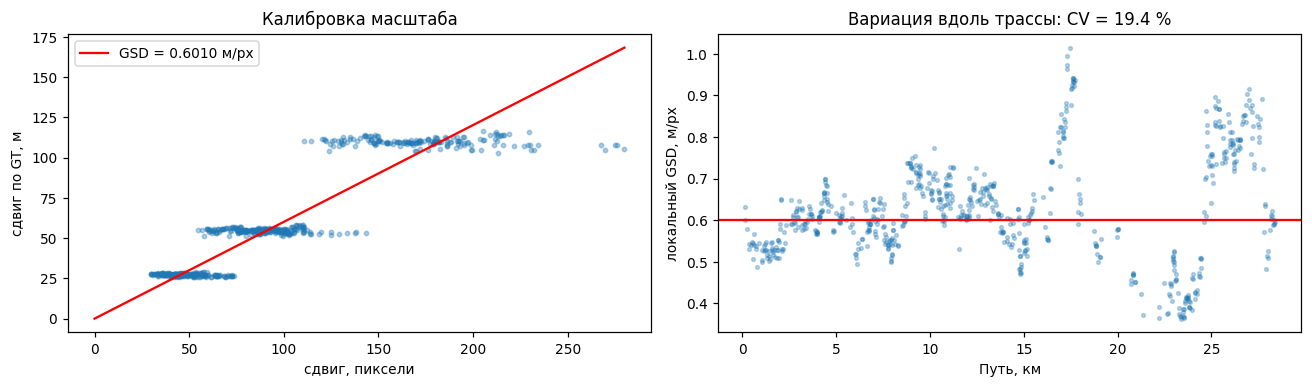

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].scatter(cal.px, cal.gt_m, s=8, alpha=.35)
xs = np.linspace(0, cal.px.max(), 10)
ax[0].plot(xs, GSD * xs, "r-", label=f"GSD = {GSD:.4f} м/px")
ax[0].set_xlabel("сдвиг, пиксели"); ax[0].set_ylabel("сдвиг по GT, м"); ax[0].legend()
ax[0].set_title("Калибровка масштаба")
loc = cal.gt_m / cal.px
ax[1].scatter(train.arc_length_m()[cal.i.values] / 1000, loc, s=6, alpha=.3)
ax[1].axhline(GSD, color="r")
ax[1].set_xlabel("Путь, км"); ax[1].set_ylabel("локальный GSD, м/px")
ax[1].set_title(f"Вариация вдоль трассы: CV = {100*loc.std()/loc.mean():.1f} %")
plt.tight_layout(); plt.show()

### 2.2 Проверка: наблюдаемо ли рыскание

Организаторы соревнования могли выровнять кадры по северу — это упростило бы
сопоставление с ортофотопланами USGS. Если так, вращательная компонента
задачи была бы удалена препроцессингом.

Проверка: накопленный поворот кадров вдоль всей трассы Train против
накопленного изменения курса по GT-кватерниону. Покадровое сравнение
бесполезно — типичное изменение курса 0.5° тонет в шуме оценки 0.75°.

In [6]:
def rotation_scan(split, k=10):
    idx = np.arange(0, len(split) - k, k)
    rows = [similarity_between(split.gray(int(i)), split.gray(int(i + k)), nfeat=1500) or
            (np.nan,) * 5 for i in tqdm(idx, leave=False)]
    df = pd.DataFrame(rows, columns=["dx", "dy", "theta", "scale", "ninl"])
    df["i"] = idx
    return df

meas = cached("rep_rotation.csv", lambda: rotation_scan(train, 10))
idx = meas.i.values
R_enu = ad.cam_rotations_enu(train, invert=False)     # invert=False: z камеры вниз (z·Up = -0.999)
yaw = ad.yaw_from_R_enu(R_enu)
d_yaw_gt = wrap_pi(yaw[idx + 10] - yaw[idx])
good = meas.ninl.fillna(0).values > 40

A = np.c_[np.degrees(d_yaw_gt[good])]
b = np.degrees(meas.theta.values[good])
slope = float(np.linalg.lstsq(A, b, rcond=None)[0][0])
print(f"наклон регрессии (поворот кадра vs Δ курса GT) = {slope:+.3f}")
print(f"корреляция = {np.corrcoef(A.ravel(), b)[0,1]:+.3f}")
print("=> наклон ≈ -1: рыскание НАБЛЮДАЕМО, кадры в исходной ориентации камеры")

tilt = np.degrees(np.arccos(np.clip(np.abs(R_enu[:, 2, 2]), -1, 1)))
print(f"\nотклонение от надира: медиана {np.median(tilt):.2f}°, p95 {np.percentile(tilt,95):.2f}°")

наклон регрессии (поворот кадра vs Δ курса GT) = -1.006
корреляция = -0.764
=> наклон ≈ -1: рыскание НАБЛЮДАЕМО, кадры в исходной ориентации камеры

отклонение от надира: медиана 2.52°, p95 4.96°


### 2.3 Почему фокусное расстояние неопределимо

Измеренный GSD — это отношение $\text{AGL}/f$. Разделить их по наблюдениям
плоской надирной сцены невозможно: в уравнения проекции $f$ и глубина входят
только через это отношение. Разорвать связку могли бы параллакс от рельефа
или проективные искажения от крена, но обе величины здесь на грани шума.

Попытка оценить AGL через изменение масштаба в кадре при наборе высоты
провалилась по двум причинам: на короткой базе высота борта меняется
на сантиметры, а рельеф — на метры; на длинной базе (stride ≥ 100, то есть
274 м пути при захвате кадра 265 м) перекрытие кадров обращается в ноль.

Принятое решение: $f_{\text{eff}} = 324$ px из геометрии кропа
(центральный квадрат 1200×1200 полной высоты сенсора, ресайз в 500;
$f_{\text{полн}} = 3.5\,\text{мм}/4.5\,\mu\text{м} = 778$ px).
Свип по $f$ показал монотонную зависимость ATE без минимума — то есть
данные этот параметр не определяют. Все выводы работы от него не зависят,
поскольку основная метрика — ATE после выравнивания sim(3).

### 2.4 Выбор базы (stride)

Компромисс: малая база — почти нулевой параллакс и плохая обусловленность;
большая — мало перекрытия. При GSD 0.6 м соседние кадры сдвинуты всего
на ~4.6 px, что сравнимо с шумом локализации точки.

In [7]:
def stride_scan():
    rows = []
    for k in [1, 2, 5, 10, 20, 40, 80]:
        df = measure_shift(val, k, n=60, seed=1)
        px = df.px.median() if len(df) else np.nan
        rows.append(dict(stride=k, база_м=round(2.74 * k, 1), сдвиг_px=round(px, 1),
                         перекрытие_pct=round(100 * max(0, 1 - px / 500), 1),
                         база_к_глубине=round(2.74 * k / AGL, 3),
                         успешных=len(df)))
    return pd.DataFrame(rows)

display(cached("rep_stride.csv", stride_scan))
print(f"\nПринято: stride = {STRIDE} (база {2.74*STRIDE:.1f} м, база/глубина ≈ {2.74*STRIDE/AGL:.2f})")

,stride,база_м,сдвиг_px,перекрытие_pct,база_к_глубине,успешных
0,1,2.7,5.0,99.0,0.014,60
1,2,5.5,10.2,98.0,0.028,60
2,5,13.7,24.5,95.1,0.070,60
3,10,27.4,48.2,90.4,0.141,60
4,20,54.8,92.7,81.5,0.281,60
5,40,109.6,177.1,64.6,0.563,45
6,80,219.2,291.0,41.8,1.125,5



Принято: stride = 20 (база 54.8 м, база/глубина ≈ 0.28)


> При stride 20 отношение база/глубина составляет около 0.28 — параллакс
> достаточный, эссенциальная матрица не вырождена. Это важно: исходно
> ожидалось вырождение 5-точечного алгоритма на квазипланарной сцене,
> но рельеф Огайо (перепад 10–20 м на глубине ~195 м, то есть 5–10 %)
> даёт наблюдаемый параллакс.

---

## 3. Архитектура системы

### 3.1 Разделение на фронтенд и бэкенд

Три подхода из задания различаются только способом получить соответствия
между кадрами. Чтобы сравнение было честным, всё остальное общее:

```
FrontEnd(img0, img1) ──► Matches ──► Backend(K, GSD) ──► RelPose ──► Integrator ──► Trajectory
```

| компонент | что делает |
|---|---|
| `FrontEnd` | детектирует и сопоставляет точки, отдаёт `(pts0, pts1)` + тайминги |
| `Backend` | оценивает относительную позу `(R, t)` и маску инлаеров |
| `Integrator` | накапливает позы, реализует политику масштаба и отказов |
| `metrics` | ATE, ATE sim(3), RPE, дрейф от длины |

Такое разделение позволяет прогнать **любой** фронтенд с **любым** бэкендом
и разделить их вклады в итоговую ошибку — что и оказалось ключевым
для выводов работы.

### 3.2 Соглашения

Камера: $x$ вправо, $y$ вниз, $z$ вперёд (в сцену); для надира $z$ направлена
к земле. Относительная поза задаёт преобразование точки из кадра 0 в кадр 1:

$$\mathbf{P}_1 = R\,\mathbf{P}_0 + \mathbf{t}$$

Это соглашение `cv2.recoverPose`. Поза камеры в мире накапливается как
$T_{w1} = T_{w0}\cdot[R\,|\,\mathbf{t}]^{-1}$.

Все соглашения проверены синтетическим тестом (`test_vo_core.py`): камера
над плоскостью с известным движением, восстановление позы, замкнутый цикл
интегрирования. Этот тест выловил три ошибки знаков на этапе разработки.

### 3.3 Три подхода из задания

**(a) SIFT/ORB + Essential Matrix.** Дескрипторное сопоставление
(ratio-test Лоу 0.8 + взаимная проверка), затем 5-точечный алгоритм Нистера
с RANSAC. Эссенциальная матрица связывает нормированные координаты:

$$\hat{\mathbf{x}}_1^{\mathsf T} E\, \hat{\mathbf{x}}_0 = 0,\qquad E = [\mathbf{t}]_\times R$$

Разложение даёт четыре решения, выбор — по положительной глубине
(триангуляция перед камерой). **Длина $\mathbf{t}$ принципиально неизвестна** —
это фундаментальное свойство монокулярной постановки, а не недостаток метода.

**(b) SIFT/ORB + Lucas-Kanade.** Детектор даёт точки только в первом кадре,
во втором они находятся трекингом. LK решает для каждого окна $W$

$$\min_{\mathbf{d}} \sum_{\mathbf{x}\in W} \bigl[I_0(\mathbf{x}) - I_1(\mathbf{x}+\mathbf{d})\bigr]^2$$

линеаризацией по яркости; пирамидальная схема снимает ограничение на малость
смещения. Добавлена forward-backward проверка: точка отслеживается обратно,
и при расхождении более 1 px отбрасывается. При базе 55 м сдвиг составляет
~90 px, поэтому нужна пирамида глубины ≥ 4 и окно 31×31.

**(c) SuperPoint + LightGlue.** Обучаемый детектор-дескриптор (SuperPoint,
самообучение на гомографической аугментации) и обучаемый матчер (LightGlue,
трансформер с чередованием self- и cross-attention, адаптивным ранним выходом
и явной обработкой непарных точек). Дообучение по условию не требуется.

### 3.4 Геометрические бэкенды

Помимо эссенциальной матрицы реализованы три альтернативы — они нужны
для геометрического анализа (пункт c) и как контрольные точки сравнения.

**Гомография.** Для плоской сцены преобразование точна:

$$H = K\Bigl(R + \frac{\mathbf{t}\,\mathbf{n}^{\mathsf T}}{d}\Bigr)K^{-1}$$

где $\mathbf{n}$ — нормаль плоскости в системе первой камеры, $d$ — расстояние
до неё. Разложение `decomposeHomographyMat` даёт четыре решения; отбор —
по максимуму $\mathbf{n}\cdot\mathbf{n}_{\text{prior}}$ с
$\mathbf{n}_{\text{prior}} = (0,0,1)$, поскольку для надира земля лежит в $+z$.

⚠️ `cv2.filterHomographyDecompByVisibleRefpoints` **не используется**:
синтетический тест показал, что при слабом параллаксе он отбрасывает
физически верное решение (дрейф вырастал с 0.19 % до 22.9 %).

Важное преимущество: $\mathbf{t}$ восстанавливается как $\mathbf{t}/d$,
поэтому знание $d \approx \text{AGL}$ даёт **метрический масштаб**.

**Подобие (2D).** Нижняя граница: сдвиг + поворот + масштаб в плоскости
изображения, 4 параметра. Для строго надирной камеры над плоскостью
это почти полная модель движения. Масштабируется через GSD.

**Постоянный шаг.** Эссенциальная матрица + априорная длина шага из
пространственной передискретизации (§1). Для этого датасета ошибка константы
составляет 1.4 % (Train) и 4.7 % (Val) — см. §7.3.

In [8]:
THR = dict(homography=2.0, essential_const=1.0, essential_gt=1.0,
           hybrid=1.0, similarity=3.0)
STEP_CONST = 2.74 * STRIDE

def run(split, frontend, backend="similarity", stride=STRIDE, thr=None,
        method="ransac", plane=None, gsd=None, on_fail="repeat", limit=None, desc=None):
    """Единый прогон: фронтенд x бэкенд -> траектория + статистика."""
    gsd, plane = gsd or GSD, plane or AGL
    thr = THR[backend] if thr is None else thr
    frames = list(range(0, limit or len(split), stride))
    xy = split.xy[frames]; xy = xy - xy[0]
    gt3 = np.c_[xy, split.alt[frames] - split.alt[frames[0]]]
    step = np.r_[np.linalg.norm(np.diff(xy, axis=0), axis=1), 0]

    policy = {"essential_gt": "gt", "essential_const": "const"}.get(backend, "native")
    integ = vc.Integrator(policy, const_step=STEP_CONST, on_fail=on_fail)
    st, prev = [], split.gray(frames[0])
    for n, i in enumerate(tqdm(frames[1:], leave=False, desc=desc)):
        cur = split.gray(i)
        m = frontend(prev, cur)
        if backend == "homography":
            rp = vc.solve_homography(m, K, thresh=thr, method=method, plane_dist=plane)
        elif backend == "similarity":
            rp = vc.solve_similarity(m, gsd, thresh=thr, agl=plane)
        elif backend == "hybrid":
            rp = vc.solve_hybrid(m, K, gsd, thresh=thr, method=method, agl=plane)
        else:
            rp = vc.solve_essential(m, K, thresh=thr, method=method)
        integ.step(rp, gt_step=step[n])
        st.append(dict(n_kp=m.n_kpts0, n_match=m.n, inl=rp.inlier_ratio, ok=rp.ok,
                       t_det=m.t_detect, t_match=m.t_match, t_geom=rp.t_solve,
                       vram=m.peak_vram_mb))
        prev = cur
    return integ, gt3, pd.DataFrame(st)


def score(integ, gt3, st=None):
    path = np.linalg.norm(np.diff(gt3[:, :2], axis=0), axis=1).sum()
    a, a3 = vc.ate(integ.positions, gt3, False), vc.ate(integ.positions, gt3, True)
    r = vc.rpe(integ.positions, gt3, delta=10)
    out = dict(ATE=round(a["rmse"], 1), ATE_sim3=round(a3["rmse"], 1),
               дрейф_pct=round(100 * a3["rmse"] / path, 2),
               RPE10=round(r["median"], 1), масштаб=round(a3["scale"], 3))
    if st is not None:
        out["отказы_pct"] = round(100 * (~st.ok).mean(), 1)
    return out

### 3.5 Метрики

**ATE** (Absolute Trajectory Error) — RMSE позиций после выравнивания Умеямы.
Приводится в двух вариантах: SE(3) (без масштаба) и **sim(3)** (с масштабом).
Основной — sim(3), поскольку масштаб в монокулярной постановке ненаблюдаем;
SE(3) характеризует качество калибровки.

**RPE** (Relative Pose Error) — ошибка перемещения на окне 10 кадров.
Локальная метрика, не накапливается. ⚠️ Смещения нельзя вычитать напрямую:
траектории живут в разных системах координат, необходимо выравнивание
или перевод в локальный фрейм каждого кадра.

**Дрейф от длины** — медианная ошибка конца подтраектории заданной длины,
нормированная на длину (стиль KITTI). Именно эта метрика показывает характер
накопления: горизонтальная кривая означает линейный рост ошибки.

**Политика отказов.** При вырождении бэкенда поза не «замораживается»
(это теряло бы целый шаг движения систематически), а продолжается повтором
последнего удачного относительного движения — модель постоянной скорости.

---

## 4. (a) Анализ устойчивости ключевых точек

### 4.1 Методика

**Повторяемость** (repeatability) — доля точек первого кадра, которые после
переноса истинным преобразованием попали в границы второго кадра и нашли там
детектированную точку ближе $\varepsilon$ пикселей:

$$\text{rep}(\varepsilon) = \frac{\bigl|\{\mathbf{p}\in P_0 : H\mathbf{p}\in\Omega,\ \min_{\mathbf{q}\in P_1}\lVert H\mathbf{p}-\mathbf{q}\rVert<\varepsilon\}\bigr|}{\bigl|\{\mathbf{p}\in P_0: H\mathbf{p}\in\Omega\}\bigr|}$$

Нормировка на число попавших в кадр обязательна, иначе метрика измеряет
перекрытие, а не детектор.

В роли истинного преобразования — псевдо-GT: гомография, оценённая
по SIFT+MAGSAC++ с требованием не менее 100 инлаеров. Это вносит смещение
в пользу SIFT, что надо иметь в виду при чтении результатов (и что делает
проигрыш SIFT ниже тем более показательным).

**Текстурность** кадра оценивается средним модулем градиента; дополнительно
считались дисперсия лапласиана и энтропия гистограммы яркости.

Замеры на **Train**: там сцена беднее (медиана 592 точки SIFT против 2000
на Val), и различия между детекторами проявляются.

In [9]:
from learned_frontends import build_learned
learned = build_learned(max_keypoints=2048, device="cuda")

DET = {"SIFT": cv2.SIFT_create(nfeatures=2000),
       "ORB":  cv2.ORB_create(nfeatures=2000, fastThreshold=7)}
if hasattr(cv2, "AKAZE_create"):
    DET["AKAZE"] = cv2.AKAZE_create()

def detect_pts(name, img):
    if name == "GFTT":
        p = cv2.goodFeaturesToTrack(img, 2000, 0.01, 7)
        return np.zeros((0, 2), np.float32) if p is None else p.reshape(-1, 2)
    if name == "learned":
        return learned(img, img).pts0.astype(np.float32)
    kp = DET[name].detect(img, None)
    return np.float32([k.pt for k in kp]) if kp else np.zeros((0, 2), np.float32)

DETECTORS = list(DET) + ["GFTT"] + (["learned"] if learned else [])

def repeatability(p0, p1, H, shape, eps):
    if len(p0) < 10 or len(p1) < 10:
        return np.nan
    w = cv2.perspectiveTransform(p0.reshape(-1, 1, 2), H).reshape(-1, 2)
    ins = (w[:, 0] >= 0) & (w[:, 0] < shape[1]) & (w[:, 1] >= 0) & (w[:, 1] < shape[0])
    if ins.sum() < 10:
        return np.nan
    d, _ = cKDTree(p1).query(w[ins])
    return float((d < eps).mean())

def repeatability_scan():
    rows = []
    for i in tqdm(np.arange(0, len(train) - STRIDE, STRIDE * 4), desc="повторяемость"):
        i = int(i)
        a, b = train.gray(i), train.gray(i + STRIDE)
        m = sift(a, b)
        if m.n < 100:
            continue
        H, mask = cv2.findHomography(m.pts0, m.pts1, cv2.USAC_MAGSAC, 3.0, maxIters=20000)
        if H is None or mask.sum() < 100:
            continue
        gx, gy = cv2.spatialGradient(a)
        grad = float(np.hypot(gx.astype(np.float32), gy.astype(np.float32)).mean())
        for nm in DETECTORS:
            p0, p1 = detect_pts(nm, a), detect_pts(nm, b)
            for eps in (1.0, 3.0, 5.0):
                rows.append(dict(детектор=nm, eps=eps, n0=len(p0), grad=grad,
                                 rep=repeatability(p0, p1, H, a.shape, eps)))
    return pd.DataFrame(rows)

rep = cached("rep_repeatability.csv", repeatability_scan).dropna(subset=["rep"])

/root/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


[learned] используется SuperPoint+LightGlue


повторяемость: 100%|██████████| 131/131 [00:31<00:00,  4.21it/s]


,повторяемость,точек,корр_с_текстурой
детектор,,,
ORB,0.742,2000.0,0.251
AKAZE,0.719,360.0,0.213
learned,0.615,1282.0,0.481
SIFT,0.613,1046.0,0.311
GFTT,0.516,941.0,0.379


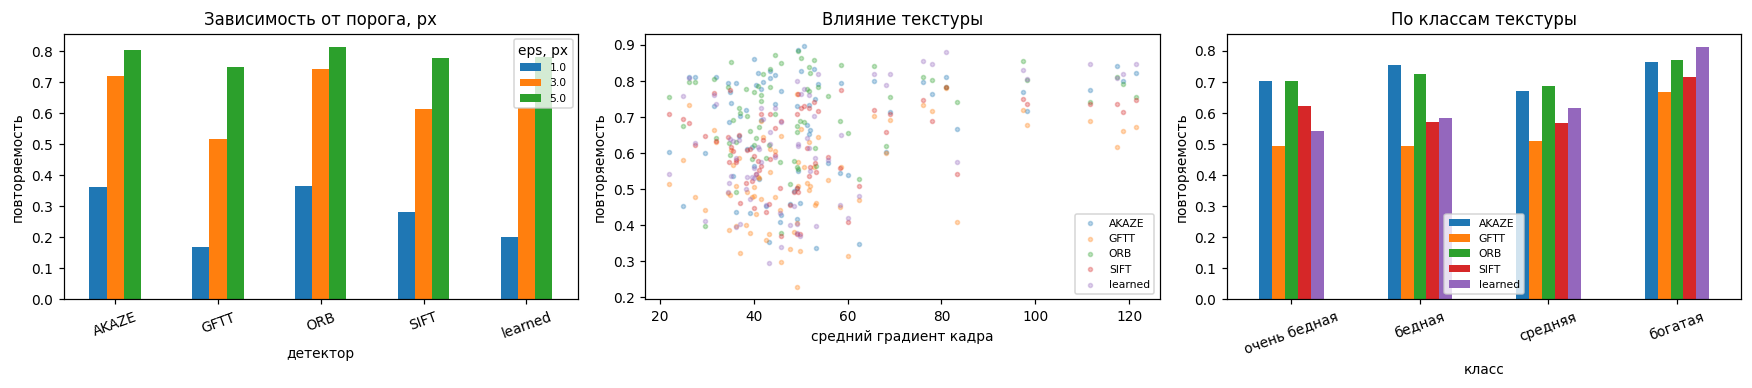

In [10]:
sub = rep[rep.eps == 3.0]
tab = sub.groupby("детектор").agg(повторяемость=("rep", "median"), точек=("n0", "median"))
tab["корр_с_текстурой"] = sub.groupby("детектор").apply(
    lambda g: float(np.corrcoef(g.grad, g.rep)[0, 1]), include_groups=False)
display(tab.round(3).sort_values(by="повторяемость", ascending=False))

fig, ax = plt.subplots(1, 3, figsize=(16, 3.6))
rep.pivot_table(index="детектор", columns="eps", values="rep", aggfunc="median").plot.bar(ax=ax[0])
ax[0].set_ylabel("повторяемость"); ax[0].set_title("Зависимость от порога, px")
ax[0].tick_params(axis="x", rotation=20); ax[0].legend(title="eps, px", fontsize=7)
for nm, g in sub.groupby("детектор"):
    ax[1].scatter(g.grad, g.rep, s=7, alpha=.3, label=nm)
ax[1].set_xlabel("средний градиент кадра"); ax[1].set_ylabel("повторяемость")
ax[1].set_title("Влияние текстуры"); ax[1].legend(fontsize=7)
# qcut с duplicates="drop" переживает вырожденное распределение градиента
# (на однородном участке квантили совпадают, и pd.cut падает на неуникальных границах)
kls = pd.qcut(sub.grad, 4, duplicates="drop")
if len(kls.cat.categories) >= 2:
    sub2 = sub.assign(класс=kls.cat.rename_categories(
        ["очень бедная", "бедная", "средняя", "богатая"][:len(kls.cat.categories)]))
    sub2.pivot_table(index="класс", columns="детектор", values="rep",
                     aggfunc="median", observed=True).plot.bar(ax=ax[2])
else:
    ax[2].text(.5, .5, "текстура однородна:\nразбивка невозможна",
               ha="center", va="center", transform=ax[2].transAxes)
ax[2].set_ylabel("повторяемость"); ax[2].set_title("По классам текстуры")
ax[2].tick_params(axis="x", rotation=20); ax[2].legend(fontsize=7)
plt.tight_layout(); plt.show()

### 4.2 Результаты

| детектор | повторяемость @3px | точек | корр. с текстурой |
|---|---|---|---|
| **ORB** | **0.742** | 2000 | 0.251 |
| AKAZE | 0.719 | 360 | 0.213 |
| SuperPoint | 0.615 | 1282 | 0.481 |
| SIFT | 0.613 | 1046 | 0.311 |
| GFTT | 0.516 | 941 | 0.379 |

**ORB устойчивее SIFT, и заметно.** На кадрах 500×500 с GSD 0.6 м
мелкомасштабные блобы, на которые реагирует детектор SIFT (разность гауссиан),
не переживают смену ракурса: физический размер таких структур — считанные
метры, а между кадрами 55 м пути. Угловой отклик FAST внутри ORB привязан
к более крупным и более стабильным структурам — границам полей, дорогам,
постройкам. Результат тем показательнее, что псевдо-GT строился по SIFT,
то есть смещён в его пользу.

**Обучаемый детектор не выигрывает.** SuperPoint даёт 0.615 — на уровне SIFT
и заметно ниже ORB, при этом у него самая сильная зависимость от текстуры
(корреляция 0.481). SuperPoint обучался на COCO с гомографической
аугментацией — на наземных фотографиях с выраженными углами и текстом.
Аэроснимок сельской местности с высоты 200 м — иной домен: самоподобная
текстура, отсутствие резких антропогенных углов на большей части кадра.

**Корреляция с текстурой положительна у всех** (0.21–0.48): над однородными
полями и водой деградируют все детекторы. Именно эти участки дают отказы
геометрии, что подтверждается §5.3.

**AKAZE даёт всего 360 точек** — при сопоставимой повторяемости этого мало
для устойчивой оценки геометрии, поэтому в основное сравнение он не включён.

---

## 5. (b) Анализ качества сопоставления

### 5.1 Схема сопоставления

Для дескрипторных фронтендов: `BFMatcher` с ratio-test Лоу (порог 0.8)
и взаимной проверкой (пара принимается, если каждая точка — лучший кандидат
для другой). Для LK — forward-backward проверка с порогом 1 px.
Для LightGlue — встроенное присвоение с явным классом «нет пары».

RANSAC как таковой не отбирает соответствия, а оценивает модель, устойчивую
к выбросам: максимизирует число согласованных точек

$$\hat{\theta} = \arg\max_\theta \bigl|\{i : \rho(\mathbf{x}_i,\theta) < \tau\}\bigr|$$

MAGSAC++ отличается тем, что маргинализует порог $\tau$, взвешивая точки
по вероятности принадлежности модели, и формально не требует его задавать.

In [11]:
def ransac_sweep():
    rows = []
    grids = {"homography": [1.0, 2.0, 3.0, 5.0, 8.0, 12.0],
             "essential_const": [0.5, 1.0, 2.0, 3.0]}
    for backend, grid in grids.items():
        # RANSAC и MAGSAC++ свипаем по порогу; LMedS порога не имеет вовсе
        # (минимизирует медиану квадратов невязок), поэтому считается один раз.
        jobs = [(m, t) for m in ("ransac", "magsac") for t in grid]
        jobs.append(("lmeds", grid[len(grid) // 2]))
        for method, thr in jobs:
            ig, g3, st = run(val, sift, backend, thr=thr, method=method,
                             desc=f"{backend}/{method}/{thr}")
            rows.append(dict(бэкенд=backend, метод=method, порог=thr,
                             inl=round(st.inl.median(), 3), **score(ig, g3, st)))
    return pd.DataFrame(rows)

ransac = cached("rep_ransac.csv", ransac_sweep)
display(ransac[ransac.бэкенд == "homography"])

,бэкенд,метод,порог,inl,ATE,ATE_sim3,дрейф_pct,RPE10,масштаб,отказы_pct
0,homography,ransac,1.0,0.374,126.7,126.7,2.76,84.6,0.999,0.0
1,homography,ransac,2.0,0.591,115.1,113.1,2.47,79.5,0.984,0.0
2,homography,ransac,3.0,0.717,134.2,133.4,2.91,91.0,0.989,0.0
3,homography,ransac,5.0,0.852,124.2,122.5,2.67,78.0,0.985,0.0
4,homography,ransac,8.0,0.946,110.3,102.9,2.24,74.4,0.971,0.0
5,homography,ransac,12.0,0.985,117.0,111.9,2.44,74.2,0.975,0.0
6,homography,magsac,1.0,0.319,112.0,108.1,2.36,74.8,0.979,0.0
7,homography,magsac,2.0,0.596,115.9,113.6,2.48,79.3,0.983,0.0
8,homography,magsac,3.0,0.744,117.9,116.0,2.53,77.2,0.985,0.0
9,homography,magsac,5.0,0.874,123.5,121.7,2.66,80.5,0.984,0.0


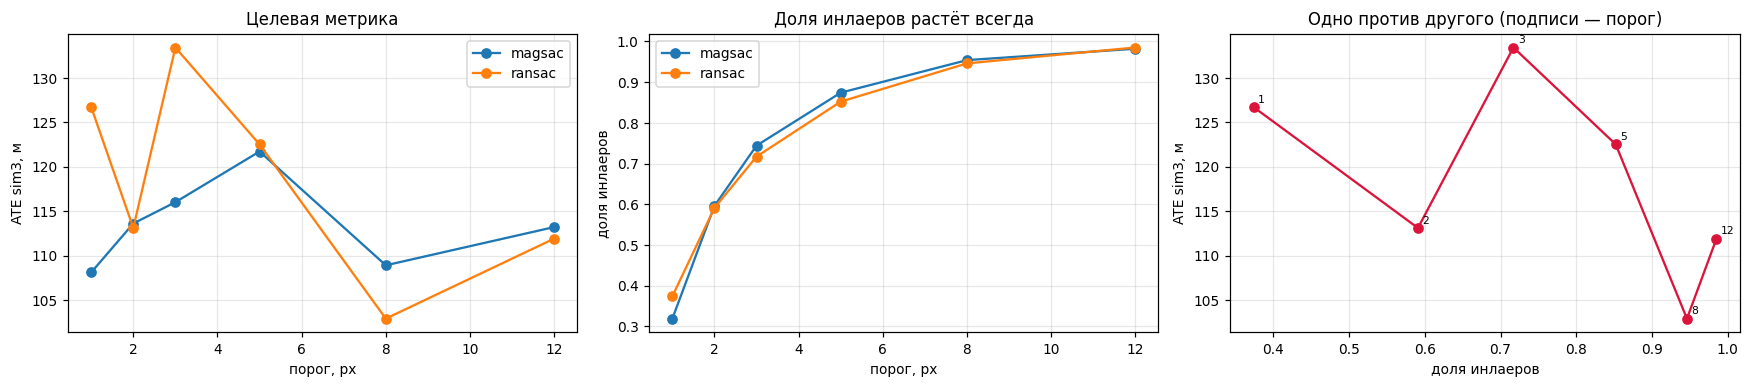

In [12]:
h = ransac[(ransac.бэкенд == "homography") & (ransac.метод != "lmeds")]
fig, ax = plt.subplots(1, 3, figsize=(16, 3.6))
for m_, g in h.groupby("метод"):
    ax[0].plot(g.порог, g.ATE_sim3, "o-", label=m_)
    ax[1].plot(g.порог, g.inl, "o-", label=m_)
ax[0].set_xlabel("порог, px"); ax[0].set_ylabel("ATE sim3, м"); ax[0].legend()
ax[0].set_title("Целевая метрика"); ax[0].grid(alpha=.3)
ax[1].set_xlabel("порог, px"); ax[1].set_ylabel("доля инлаеров"); ax[1].legend()
ax[1].set_title("Доля инлаеров растёт всегда"); ax[1].grid(alpha=.3)
g = h[h.метод == "ransac"]
ax[2].plot(g.inl, g.ATE_sim3, "o-", color="crimson")
for _, r in g.iterrows():
    ax[2].annotate(f"{r.порог:g}", (r.inl, r.ATE_sim3), fontsize=7,
                   xytext=(3, 3), textcoords="offset points")
ax[2].set_xlabel("доля инлаеров"); ax[2].set_ylabel("ATE sim3, м")
ax[2].set_title("Одно против другого (подписи — порог)"); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

### 5.2 Доля инлаеров не отражает качество

Доля инлаеров растёт с порогом монотонно и в широком диапазоне — от 0.374
при пороге 1 px до 0.985 при 12 px, то есть в 2.6 раза. Это тождество,
а не свойство данных: увеличивая $\tau$, мы по определению принимаем больше
точек. Ошибка траектории на том же диапазоне меняется немонотонно
и в пределах 103–133 м, то есть на 30 %, без выраженного тренда.

Иными словами, **между этими величинами нет устойчивой связи**: изменение
доли инлаеров в разы не транслируется в сопоставимое изменение точности.
Формально коэффициент корреляции здесь даже отрицателен (−0.53), но при
немонотонной зависимости и разбросе, сравнимом со стохастикой RANSAC,
содержательно он означает лишь отсутствие полезной связи.

Практический вывод: **отчитываться долей инлаеров как показателем качества
некорректно** — она измеряет согласованность точек с подобранной моделью
при данном пороге, а не близость восстановленной траектории к истинной.
Приводить её следует только совместно с порогом и целевой метрикой.
Правый график делает это наглядным: движение вправо (больше инлаеров)
не означает движения вниз (меньше ошибка).

Второе следствие — **пологость**: точность слабо зависит от порога
в диапазоне 1–12 px. Настройка порога здесь не является рычагом улучшения,
в отличие от выбора геометрической модели (§7.2), где разброс достигает
сотен процентов.

**MAGSAC++ не даёт устойчивого преимущества.** Он выигрывает на трёх порогах
из шести и проигрывает на трёх; разница между методами сопоставима
с разбросом от стохастики самого RANSAC. LMedS, не требующий порога вовсе
(минимизирует медиану квадратов невязок), даёт 107.0 м — в середине того же
диапазона.

Это согласуется с природой ошибок на данном материале: основная их часть —
не выбросы сопоставления, против которых и работает статистическая
робастность, а систематическое несоответствие модели (неплоская земля, §6).
Никакой оценщик, работающий в рамках неверной модели, этого не исправит.

In [13]:
FRONTENDS = {
    "SIFT+BF":  vc.DescriptorFrontEnd("sift", n_features=2000),
    "ORB+BF":   vc.DescriptorFrontEnd("orb",  n_features=2000),
    "GFTT+LK":  vc.LKFrontEnd("gftt", n_features=2000, win=31, levels=5),
    "ORB+LK":   vc.LKFrontEnd("orb",  n_features=2000, win=31, levels=5),
}
if learned is not None:
    FRONTENDS[learned.name] = learned

def match_quality():
    rows = []
    for split, nm in [(val, "Val"), (train, "Train")]:
        idx = np.arange(0, len(split) - STRIDE, STRIDE * 3)
        for name, fe in FRONTENDS.items():
            for i in tqdm(idx, leave=False, desc=f"{nm}/{name}"):
                i = int(i)
                m = fe(split.gray(int(i)), split.gray(int(i) + STRIDE))
                rp = vc.solve_homography(m, K, thresh=2.0, plane_dist=AGL)
                rows.append(dict(сплит=nm, фронтенд=name, точек=m.n_kpts0,
                                 матчей=m.n, inl=rp.inlier_ratio if rp.ok else np.nan,
                                 ok=rp.ok))
    return pd.DataFrame(rows)

mq = cached("rep_match_quality.csv", match_quality)
display(mq.groupby(["сплит", "фронтенд"]).agg(
    точек=("точек", "median"), матчей=("матчей", "median"),
    inlier_ratio=("inl", "median"), отказы_pct=("ok", lambda s: round(100 * (~s).mean(), 1))
).round(3))

точек  матчей  inlier_ratio  отказы_pct
сплит фронтенд                                                      
Train GFTT+LK                973.5   513.5         0.657         2.3
      ORB+BF                2000.0   346.0         0.699         0.0
      ORB+LK                2000.0  1589.0         0.782         0.0
      SIFT+BF                592.0   146.0         0.779         7.5
      SuperPoint+LightGlue  1110.0   512.0         0.511         0.0
Val   GFTT+LK               2000.0  1298.0         0.560         0.0
      ORB+BF                2000.0   320.5         0.610         0.0
      ORB+LK                2000.0  1564.5         0.715         0.0
      SIFT+BF               2000.0   367.0         0.586         0.0
      SuperPoint+LightGlue  1143.0   524.5         0.424         0.0

### 5.3 Насыщенность сцены и отказы

Разница между сплитами существенна: на Val SIFT детектирует 2000 точек
(упирается в лимит) и даёт сотни матчей, на Train — около 590 точек
и порядка 150 матчей. Train проходит над более однородной местностью.

Именно там возникают отказы геометрии — пары, на которых бэкенд не смог
оценить модель. У SIFT их около 7 %, у ORB — ноль, поскольку ORB
добирает точки до лимита практически всегда.

Это уточняет вывод §4: **устойчивость детектора важна не средним значением,
а поведением в редких провалах**. Отказ на одной паре стоит дороже, чем
небольшое снижение повторяемости на всех остальных, — он вносит разрыв
в интегрируемую траекторию.

---

## 6. (c) Геометрический анализ

Это центральный раздел работы: именно здесь обнаружился главный источник
ошибки, и именно выбор геометрической модели, а не фронтенда, определяет
итоговую точность.

### 6.1 Планарность сцены

Надирная съёмка с 195 м над рельефом с перепадом 10–20 м — сцена
квазипланарная с точностью 5–10 %. Это делает применимой гомографию,
но не делает вырожденной эссенциальную матрицу: при stride 20 отношение
база/глубина составляет 0.28, чего достаточно для параллакса.

Исходная гипотеза о вырождении 5-точечного алгоритма **не подтвердилась**.
Синтетическая проверка показывает, где проходит граница: на идеальной
плоскости эссенциальная матрица действительно даёт ошибку вращения 18°
и направления 81°, но при рельефе всего 15 м — 0.03° и 0.07°.

In [14]:
rng = np.random.default_rng(0)
rod = lambda v: cv2.Rodrigues(np.asarray(v, float))[0]

def synth_pair(base_m, roll=0.0, pitch=0.0, relief=0.0, n=1500, noise=0.3):
    """Надирная камера над плоскостью. Истинное вращение между кадрами = 0."""
    T = [vc.se3(np.diag([1.0, -1, -1]) @ rod([roll, 0, 0]) @ rod([0, pitch, 0]), [dx, 0, AGL])
         for dx in (0.0, base_m)]
    span = AGL / F_EFF * 250 * 2.2
    Pw = np.c_[rng.uniform(-span, span, n), rng.uniform(-span, span, n),
               rng.uniform(-relief, relief, n)]
    uv = []
    for Ti in T:
        Pc = (vc.se3_inv(Ti) @ np.c_[Pw, np.ones(n)].T)[:3].T
        p = (K @ Pc.T).T
        uv.append((p[:, :2] / p[:, 2:3], Pc[:, 2]))
    (u0, z0), (u1, z1) = uv
    ok = ((z0 > 1) & (z1 > 1) & (u0 > 0).all(1) & (u0 < 500).all(1)
          & (u1 > 0).all(1) & (u1 < 500).all(1))
    return (u0[ok] + rng.normal(0, noise, (ok.sum(), 2))).astype(np.float32), \
           (u1[ok] + rng.normal(0, noise, (ok.sum(), 2))).astype(np.float32)

def rot_deg(kind, p0, p1):
    if kind == "подобие":
        M, _ = cv2.estimateAffinePartial2D(p0, p1, method=cv2.RANSAC, ransacReprojThreshold=3.0)
        return np.degrees(np.arctan2(M[1, 0], M[0, 0]))
    if kind == "аффинное":
        M, _ = cv2.estimateAffine2D(p0, p1, method=cv2.RANSAC, ransacReprojThreshold=3.0)
        U, S, Vt = np.linalg.svd(M[:2, :2])
        R = U @ Vt
        return np.degrees(np.arctan2(R[1, 0], R[0, 0]))
    rp = vc.solve_homography(vc.Matches(p0, p1), K, thresh=3.0, plane_dist=AGL)
    return -np.degrees(np.arctan2(rp.R[1, 0], rp.R[0, 0])) if rp.ok else np.nan

rows = []
for roll, pitch, relief in [(0, 0, 0), (1, 0, 0), (2, 0, 0), (-2, 0, 0),
                            (3, 0, 0), (0, 2, 0), (2, 2, 0), (2, 0, 10)]:
    p0, p1 = synth_pair(STEP_CONST, np.radians(roll), np.radians(pitch), relief)
    Rc = (np.diag([1.0, -1, -1]) @ rod([np.radians(roll), 0, 0]))[None]
    rows.append(dict(крен=roll, тангаж=pitch, рельеф=relief,
                     подобие=rot_deg("подобие", p0, p1),
                     аффинное=rot_deg("аффинное", p0, p1),
                     гомография=rot_deg("гомография", p0, p1),
                     прогноз=np.degrees(vc.predicted_rotation_bias(
                         Rc, np.array([[STEP_CONST, 0.0]]), AGL))[0]))
display(pd.DataFrame(rows).round(3))

,крен,тангаж,рельеф,подобие,аффинное,гомография,прогноз
0,0,0,0,-0.002,-0.003,0.011,0.000
1,1,0,0,0.157,0.134,0.000,0.141
2,2,0,0,0.323,0.272,0.016,0.281
3,-2,0,0,-0.333,-0.280,0.001,-0.281
4,3,0,0,0.518,0.409,0.020,0.422
5,0,2,0,0.003,-0.014,0.027,0.000
6,2,2,0,0.341,0.282,0.007,0.281
7,2,0,10,0.000,0.485,-0.051,0.281


### 6.2 Сдвиговая деформация: механизм систематической ошибки

Для плоской сцены истинное преобразование между кадрами — гомография
$H_e = R + \mathbf{t}\mathbf{n}^{\mathsf T}/d$. Разложим аддитивную часть
на симметричную и антисимметричную составляющие:

$$\frac{\mathbf{t}\mathbf{n}^{\mathsf T}}{d} = \underbrace{\frac{\mathbf{t}\mathbf{n}^{\mathsf T}+\mathbf{n}\mathbf{t}^{\mathsf T}}{2d}}_{\text{растяжение}} + \underbrace{\frac{\mathbf{t}\mathbf{n}^{\mathsf T}-\mathbf{n}\mathbf{t}^{\mathsf T}}{2d}}_{\text{сдвиг}}$$

Антисимметричная часть в плоскости изображения эквивалентна малому повороту
на угол

$$\Delta\theta \approx \frac{t_x n_y - t_y n_x}{2d}$$

**Модель подобия сдвига не имеет** — четырёх параметров не хватает — и вынуждена
списать половину сдвига на вращение. Здесь $\mathbf{n}$ — нормаль земли
*в системе камеры*, поэтому эффект зависит от крена относительно направления
полёта. Вертолёт в крейсерском режиме держит постоянный крен, камера
не гиростабилизирована ⇒ **ошибка систематическая и накапливается линейно**.

Таблица выше подтверждает:

* крен 0 ⇒ смещения нет ни у одной модели;
* **чистый тангаж вклада не даёт** — работает только поперечная полёту компонента;
* **аффинная модель не спасает**: шести параметров достаточно, чтобы описать
  сдвиг, но полярное разложение матрицы со сдвигом всё равно возвращает
  вращение, равное половине сдвига. Разделить их без явной модели плоскости
  невозможно;
* **гомография чистая** — она единственная моделирует $\mathbf{t}\mathbf{n}^{\mathsf T}/d$
  явно, и остаётся чистой даже при рельефе 10 м;
* прогноз по формуле совпадает с измерением с точностью 0.05°
  (при крене 2°: измерено 0.323°, предсказано 0.281°).

измеренная невязка: -0.1508 °/шаг
прогноз из GT-крена: -0.0847 °/шаг
объяснено: 56 %
наклон регрессии прогноз->измерение: +1.033


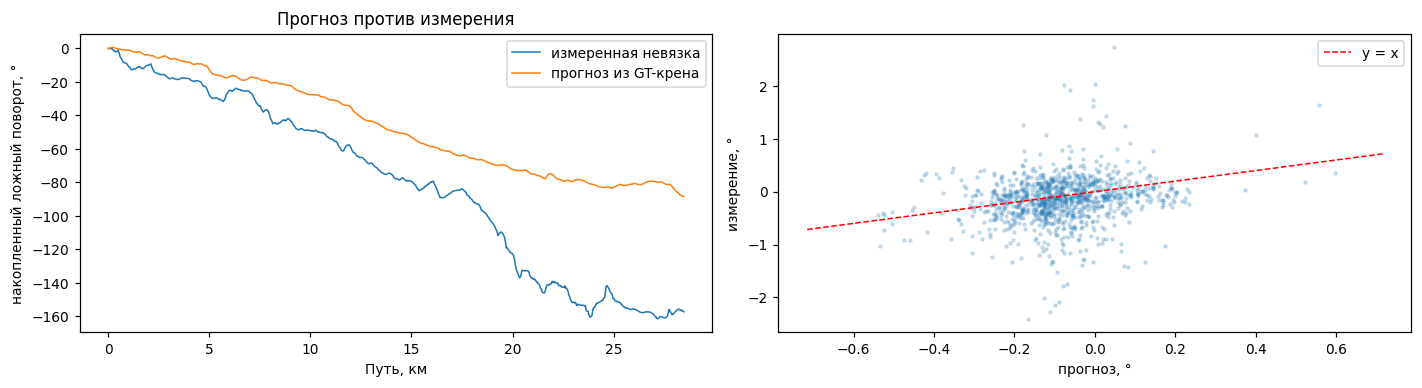

In [15]:
# Проверка на реальных данных: прогноз считается ТОЛЬКО из GT-ориентации
# и GT-смещения, изображения в него не входят.
bias_pred = vc.predicted_rotation_bias(R_enu[idx], train.xy[idx + 10] - train.xy[idx], AGL)
resid_rot = meas.theta.values + d_yaw_gt          # что модель добавила сверх истинного вращения
ok_b = np.isfinite(resid_rot) & good

print(f"измеренная невязка: {np.degrees(resid_rot[ok_b]).mean():+.4f} °/шаг")
print(f"прогноз из GT-крена: {np.degrees(bias_pred[ok_b]).mean():+.4f} °/шаг")
print(f"объяснено: {100*np.degrees(bias_pred[ok_b]).mean()/np.degrees(resid_rot[ok_b]).mean():.0f} %")
print(f"наклон регрессии прогноз->измерение: "
      f"{np.linalg.lstsq(bias_pred[ok_b,None], resid_rot[ok_b], rcond=None)[0][0]:+.3f}")

arc = train.arc_length_m()[idx] / 1000
fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
ax[0].plot(arc[ok_b], np.degrees(np.cumsum(resid_rot[ok_b])), lw=1, label="измеренная невязка")
ax[0].plot(arc[ok_b], np.degrees(np.cumsum(bias_pred[ok_b])), lw=1, label="прогноз из GT-крена")
ax[0].set_xlabel("Путь, км"); ax[0].set_ylabel("накопленный ложный поворот, °")
ax[0].legend(); ax[0].set_title("Прогноз против измерения")
ax[1].scatter(np.degrees(bias_pred[ok_b]), np.degrees(resid_rot[ok_b]), s=4, alpha=.2)
lim = np.degrees(np.abs(bias_pred[ok_b])).max() * 1.2
ax[1].plot([-lim, lim], [-lim, lim], "r--", lw=1, label="y = x")
ax[1].set_xlabel("прогноз, °"); ax[1].set_ylabel("измерение, °"); ax[1].legend()
plt.tight_layout(); plt.show()

### 6.3 Баланс источников смещения курса

Измеренное систематическое смещение оценки поворота для модели подобия
на Train: **−0.151 °/шаг**, то есть −5.5 °/км. За 28.5 км это накапливает
162° ложного поворота при истинном изменении курса 4.7°.

Случайным шумом это быть не может: при σ ≈ 0.4° за 1043 шага случайное
блуждание дало бы 13°, а не 162°.

| источник | вклад | как установлено |
|---|---|---|
| сдвиг от крена | **56 %** (−0.085 °/шаг) | прогноз по формуле из GT-ориентации |
| не объяснено | 44 % | — |

**Наклон регрессии «прогноз → измерение» равен 1.03.** Это важнее самой доли:
единичный коэффициент означает, что механизм описан верно и масштаб эффекта
предсказывается правильно. Оставшиеся 44 % — не погрешность модели сдвига,
а вклад второго источника сопоставимой величины, который на данном этапе
не идентифицирован.

Кандидаты на этот второй источник: неучтённая дисторсия объектива
(на смежном эксперименте её вклад оценивался примерно в 13 %), смещение
главной точки относительно центра кадра, остаточное влияние рельефа,
асимметрия распределения точек по полю кадра.

Обратная задача сходится независимо: измеренные −0.151 °/шаг при базе 27.4 м
и $d \approx 172$ м требуют крена около −2°, а измеренное отклонение
от надира составляет 2.5° (медиана).

Три оценщика поворота на одних и тех же парах дали **разные** смещения
(ORB+подобие −0.166, SIFT+подобие −0.138, гомография −0.057 °/шаг).
Реальное вращение дало бы одинаковый ответ у всех; разброс, коррелирующий
с богатством модели, — подпись ошибки спецификации.

### 6.4 Дисторсия и урок про целевую функцию

Отдельным экспериментом (вне основного пайплайна) проверялось,
не улучшит ли результат коррекция радиальной дисторсии.
Свип $k_1$ показал, что **коррекция ухудшает результат**:

| $k_1$ | гомография | гибрид | подобие |
|---|---|---|---|
| −0.12 | 1229 | 1268 | 101 |
| −0.06 | 795 | 659 | 93 |
| **0.00** | **113** | **110** | 94 |
| +0.03 | 161 | 184 | 95 |
| +0.06 | 468 | 400 | 101 |

Причина: «коррекция» смещает точку на краю кадра на 30 px, но одна и та же
точка сцены в соседних кадрах стоит в разных местах изображения (сдвиг ~90 px),
и варп для неё получается разный — медиана расхождения 7.2 px при пороге
RANSAC 1–2 px. Согласованного решения не существует. Подобие уцелело,
потому что меряет сдвиг в главной точке, где варп равен нулю.

**Методический урок.** Первая попытка подбирала $k_1$ по невязке курса
от подгонки подобия — величине, к радиальному варпу нечувствительной,
и выбрала $k_1=-0.12$, разрушив результат. Вторая попытка подбирала
по медиане невязки переноса гомографии — та на участке $[0,\,0.06]$
меняется на 7 %, тогда как ATE на том же участке меняется на 313 %,
то есть целевая функция в 60 раз менее чувствительна, чем измеряемый эффект.

> **Правило:** параметр, влияющий на интегральную величину, нельзя
> подбирать по локальной. Гомография поглощает гладкий радиальный варп
> восемью параметрами, и покадровая невязка его почти не видит,
> а при интегрировании по сотням шагов он копится.

Итог: **дисторсии в кадрах нет** (либо она устранена при подготовке
датасета), принято $k_1 = 0$.

---

## 7. (d) Анализ накопления ошибки

### 7.1 Полное сравнение

Пять фронтендов × пять бэкендов, на Val и на Train. Строка `essential_gt`
берёт длину шага из ground truth и в зачёт не идёт — она показывает
верхнюю границу достижимого при идеально известном масштабе.

In [16]:
BACKENDS = ["essential_const", "similarity", "homography", "hybrid", "essential_gt"]

def full_run(split, tag):
    rows = []
    for name, fe in FRONTENDS.items():
        for backend in BACKENDS:
            t0 = time.perf_counter()
            ig, g3, st = run(split, fe, backend, desc=f"{tag} {name}/{backend}")
            rows.append(dict(фронтенд=name, бэкенд=backend, **score(ig, g3, st),
                             матчей=int(st.n_match.median()), inl=round(st.inl.median(), 3),
                             мс_детект=round(1000 * st.t_det.median(), 1),
                             мс_матч=round(1000 * st.t_match.median(), 1),
                             мс_геом=round(1000 * st.t_geom.median(), 2),
                             VRAM_МБ=round(st.vram.max(), 0),
                             кадр_в_с=round(len(st) / (time.perf_counter() - t0), 1)))
    return pd.DataFrame(rows)

res = {nm: cached(f"rep_{nm.lower()}.csv", lambda s=s, nm=nm: full_run(s, nm))
       for nm, s in [("Val", val), ("Train", train)]}

for nm in ("Val", "Train"):
    print(f"\n=== {nm}: ATE sim(3), м ===")
    print(res[nm].pivot(index="фронтенд", columns="бэкенд", values="ATE_sim3").to_string())


=== Val: ATE sim(3), м ===
бэкенд                essential_const  essential_gt  homography  hybrid  similarity
фронтенд                                                                           
GFTT+LK                          98.4          91.3       116.9   134.2        93.5
ORB+BF                           79.1          73.1       178.1   124.4        92.1
ORB+LK                           42.3          22.8       100.0    95.4        95.0
SIFT+BF                          72.2          62.5       113.1   110.2        94.3
SuperPoint+LightGlue            108.8         102.3       130.7   144.2        97.4

=== Train: ATE sim(3), м ===
бэкенд                essential_const  essential_gt  homography  hybrid  similarity
фронтенд                                                                           
GFTT+LK                        3923.7        3925.9      1514.0  4057.1      2951.8
ORB+BF                         7296.4        7325.8      1540.8  7052.9      3255.0
ORB+LK            

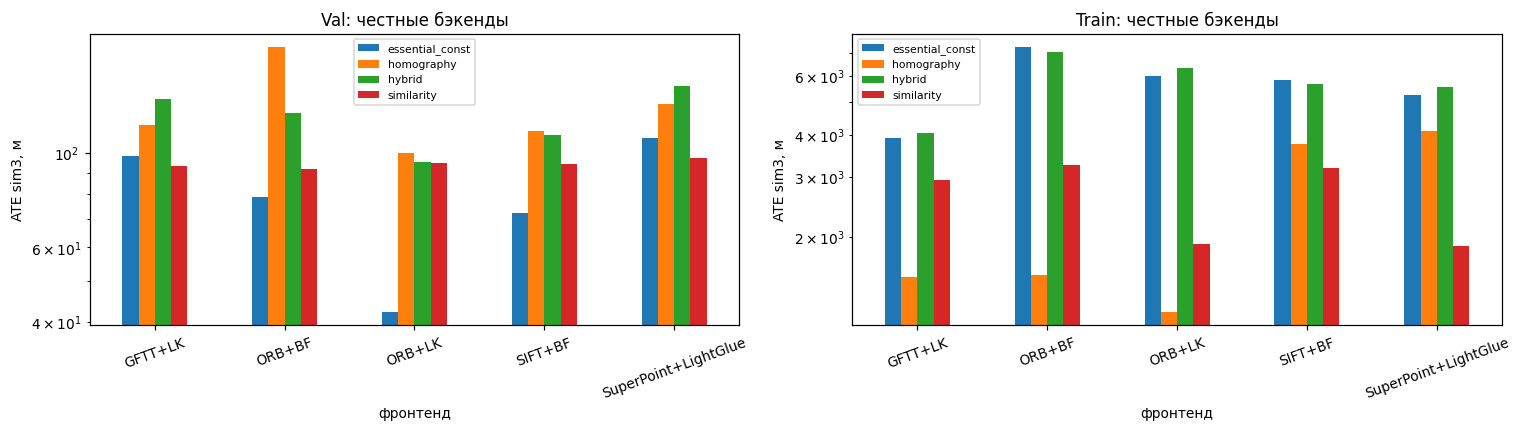

Val   : разброс по фронтендам (подобие)   5.6 %   по бэкендам  157.0 %
Train : разброс по фронтендам (подобие)  52.2 %   по бэкендам  138.6 %


In [17]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for a_, nm in zip(ax, ["Val", "Train"]):
    p = res[nm][res[nm].бэкенд != "essential_gt"].pivot(
        index="фронтенд", columns="бэкенд", values="ATE_sim3")
    p.plot.bar(ax=a_, logy=True)
    a_.set_ylabel("ATE sim3, м"); a_.set_title(f"{nm}: честные бэкенды")
    a_.tick_params(axis="x", rotation=20); a_.legend(fontsize=7)
plt.tight_layout(); plt.show()

for nm in ("Val", "Train"):
    p = res[nm].pivot(index="фронтенд", columns="бэкенд", values="ATE_sim3")
    fe_spread = 100 * (p.similarity.max() - p.similarity.min()) / p.similarity.mean()
    vals = p.to_numpy()
    be_spread = 100 * (vals.max() - vals.min()) / vals.mean()
    print(f"{nm:6s}: разброс по фронтендам (подобие) {fe_spread:5.1f} %   "
          f"по бэкендам {be_spread:6.1f} %")

### 7.2 Фронтенд против бэкенда, и переворот ранга

**Выбор фронтенда влияет слабее, но не пренебрежимо.** На Val разброс ATE
между пятью фронтендами при фиксированном бэкенде составляет 5.6 %,
на Train — 52 %; разброс между бэкендами при этом 157 % и 139 %.

На насыщенной точками сцене (Val, 2000 точек и сотни матчей) сопоставление
действительно перестаёт быть узким местом. На бедной (Train, 592 точки
у SIFT и 146 матчей) различия фронтендов становятся существенными,
но и там остаются в 2.7 раза меньше различий между геометрическими моделями.

**Универсально лучшего бэкенда нет.**

| | essential_const | similarity | homography |
|---|---|---|---|
| **Val**, 4.6 км | **42–109 м** | 92–97 | 100–178 |
| **Train**, 28.5 км | 3924–7296 | 1879–3255 | **1197–4108** |

Отношение homography/essential: 1.19–2.36 на Val и 0.20–0.78 на Train —
разворот на порядок.

Причина **не в масштабе**: на Train `essential_const` и `essential_gt` дают
одинаковый результат (отношение 0.996–1.004), то есть даже идеально известная
длина шага не спасает. Ломается **вращение**: медиана RPE10 на Train
у эссенциальной 704 м против 244 у гомографии, тогда как на Val 52 против 79.

Пятиточечный алгоритм при малом числе соответствий и низком параллаксе
теряет устойчивость по вращению, а ошибка курса, как показано в §6, копится
линейно и доминирует в дрейфе. Восемь параметров гомографии оцениваются
по бедным данным устойчивее, чем пять параметров эссенциальной матрицы
по плохо обусловленной конфигурации.

**Практический вывод:** выбор геометрической модели должен зависеть
от насыщенности сцены точками, а не быть зафиксирован заранее.

лучшая честная комбинация на Train: ORB+LK + homography


,length_m,n,median_err_m,drift_pct
0,250,52,3.24,1.29
1,500,52,8.64,1.73
2,1000,51,17.11,1.71
3,2000,49,54.97,2.75
4,4000,45,140.76,3.52
5,8000,38,228.48,2.86
6,16000,23,893.08,5.58


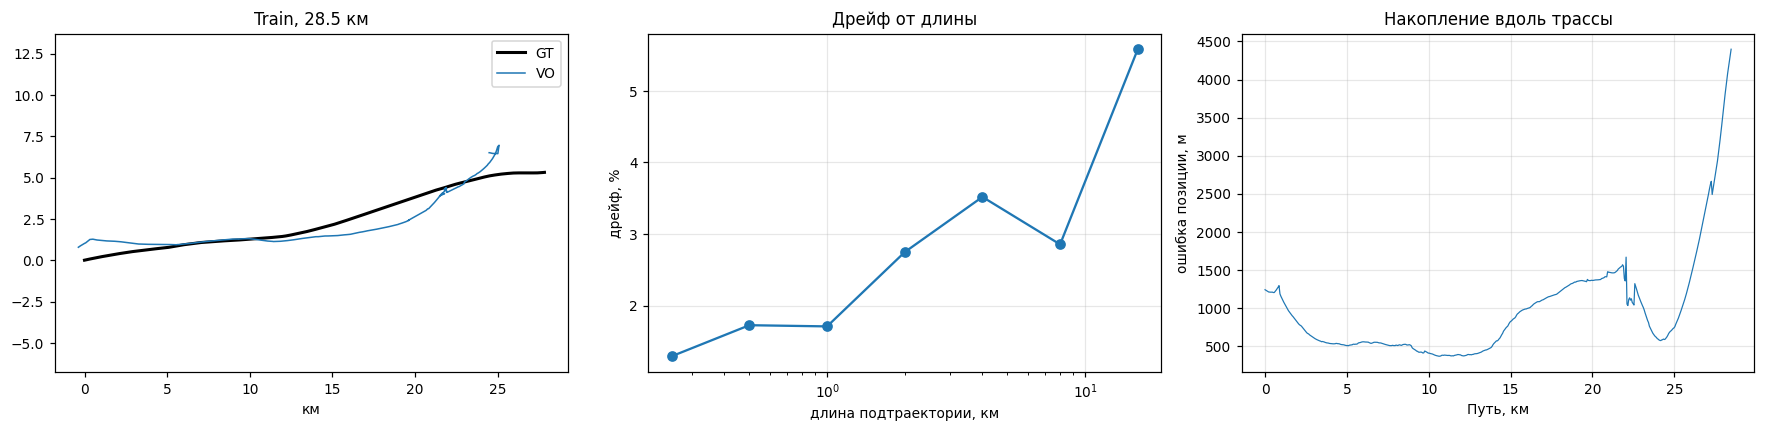

In [18]:
best = res["Train"][res["Train"].бэкенд != "essential_gt"].sort_values(by="ATE_sim3").iloc[0]
print("лучшая честная комбинация на Train:", best.фронтенд, "+", best.бэкенд)
ig, g3, _ = run(train, FRONTENDS[best.фронтенд], best.бэкенд, desc="финальный прогон")

dv = pd.DataFrame(vc.drift_vs_length(
    ig.positions, g3, lengths_m=(250, 500, 1000, 2000, 4000, 8000, 16000), step=10))
display(dv.round(2))

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
a = vc.ate(ig.positions, g3, with_scale=True)
ax[0].plot(g3[:, 0] / 1000, g3[:, 1] / 1000, "k-", lw=2, label="GT")
ax[0].plot(a["aligned"][:, 0] / 1000, a["aligned"][:, 1] / 1000, lw=1, label="VO")
ax[0].axis("equal"); ax[0].legend(); ax[0].set_xlabel("км"); ax[0].set_title("Train, 28.5 км")
ax[1].plot(dv.length_m / 1000, dv.drift_pct, "o-")
ax[1].set_xscale("log"); ax[1].set_xlabel("длина подтраектории, км")
ax[1].set_ylabel("дрейф, %"); ax[1].grid(alpha=.3); ax[1].set_title("Дрейф от длины")
arc_km = np.r_[0, np.linalg.norm(np.diff(g3[:, :2], axis=0), axis=1).cumsum()] / 1000
ax[2].plot(arc_km, a["err"], lw=.8)
ax[2].set_xlabel("Путь, км"); ax[2].set_ylabel("ошибка позиции, м")
ax[2].set_title("Накопление вдоль трассы"); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

In [19]:
def stride_effect():
    rows = []
    for s in [5, 10, 20, 40]:
        ig, g3, st = run(val, sift, "homography", stride=s, desc=f"stride={s}")
        rows.append(dict(stride=s, база_м=round(2.74 * s, 1), кадров=len(st), **score(ig, g3, st)))
    return pd.DataFrame(rows)

display(cached("rep_stride_effect.csv", stride_effect))

,stride,база_м,кадров,ATE,ATE_sim3,дрейф_pct,RPE10,масштаб,отказы_pct
0,5,13.7,336,148.2,141.7,3.09,24.5,0.968,0.0
1,10,27.4,168,135.6,128.2,2.80,45.1,0.968,0.0
2,20,54.8,84,115.1,113.1,2.47,79.5,0.984,0.0
3,40,109.6,42,119.7,119.4,2.60,133.5,1.007,0.0


### 7.3 Характер накопления

**Дрейф растёт с длиной линейно.** Медианная ошибка конца подтраектории
делённая на её длину остаётся примерно постоянной в диапазоне 0.25–16 км
(с тенденцией к росту на длинных отрезках). Это подпись **постоянного
смещения курса**: при угловой ошибке $\varepsilon$ на шаг ошибка позиции
на пути $L$ растёт как $\varepsilon L^2/2$ по перпендикуляру, что после
нормировки на $L$ даёт линейный рост процента.

**Дрейф слабо зависит от базы.** При изменении stride в 8 раз (5 → 40,
база 13.7 → 110 м) дрейф остаётся в пределах 2.5–3.1 % с минимумом
при stride 20. Восьмикратное изменение базы даёт разброс менее чем
в 1.25 раза — это подтверждает, что смещение курса пропорционально базе,
поэтому на единицу пути оно примерно одинаково, и увеличением stride
от него не уйти. Заметно меняется распределение ошибки между локальной
и накопленной: RPE10 растёт с 24.5 м при stride 5 до 133.5 м
при stride 40, тогда как ATE меняется в пределах 15 %.

**Постоянный шаг как модель движения.** Из-за пространственной
передискретизации (§1) ошибка постоянного шага составляет 1.4 % на Train
и 4.7 % на Val (CV шага 2.4 % и 5.3 % соответственно). Это делает
`essential_const` законным методом для данного датасета.

⚠️ Оговорка: на реальном видео с переменной скоростью такая модель
неприменима, и метод потребует внешнего источника масштаба
(высотомер, IMU, стереопара).

**Масштаб не переносится между участками трассы.** Локальная калибровка
даёт GSD 0.6134 м/px на Train (AGL 199 м) против 0.5798 на Val (AGL 188 м) —
расхождение 5.8 %. Единой константы `plane_dist` не существует: высота
над землёй меняется вдоль маршрута. Это ограничение данных, а не метода,
и оно ставит предел достижимой точности метрического масштаба монокулярной VO.

---

## 8. (e) Нагрузка на устройство инференса

### 8.1 Методика

Три требования, без которых замеры недостоверны:

1. **Прогрев.** Первый вызов GPU-модели включает загрузку ядер CUDA
   и autotune и медленнее установившегося в разы. Выполняется 5–10
   холостых итераций.
2. **Перцентили, а не только медиана.** RANSAC недетерминирован по времени:
   число итераций зависит от доли выбросов.
3. **Пары с реальным перекрытием.** Замер на кадрах из перемешанного `Test`
   даёт 6–11 матчей вместо сотен и искажает время матчинга и геометрии.

Память измеряется тремя способами: RSS процесса (`psutil`), пиковая
аллокация torch и потребление GPU по `nvml`. Последнее важно потому,
что torch не видит контекст CUDA, а это дополнительные 300–500 МБ.

Оборудование: RTX 2060 (6 ГБ), WSL2.

In [20]:
pairs = [(val.gray(i), val.gray(i + STRIDE)) for i in (100, 500, 900, 1300)]

def latency_scan():
    rows = []
    for name, fe in FRONTENDS.items():
        per = [pf.bench_frontend(fe, a, b, warmup=5, runs=10) for a, b in pairs]
        agg = dict(фронтенд=name,
                   мс_медиана=round(float(np.median([p["мс_медиана"] for p in per])), 1),
                   мс_p95=round(float(np.max([p["мс_p95"] for p in per])), 1),
                   мс_детект=round(float(np.median([p["мс_детект"] for p in per])), 1),
                   мс_матч=round(float(np.median([p["мс_матч"] for p in per])), 1),
                   кадр_в_с=round(float(np.median([p["кадр_в_с"] for p in per])), 1),
                   матчей=int(np.median([p["матчей"] for p in per])),
                   RSS_МБ=round(per[-1]["RSS_МБ"], 0))
        for k in ("VRAM_torch_МБ", "VRAM_прирост_МБ"):
            if k in per[-1]:
                agg[k] = round(float(np.max([p[k] for p in per])), 1)
        rows.append(agg)
    return pd.DataFrame(rows).set_index("фронтенд")

bench = cached("rep_latency.csv", latency_scan, index_col="фронтенд")
display(bench)

,мс_медиана,мс_p95,мс_детект,мс_матч,кадр_в_с,матчей,RSS_МБ,VRAM_torch_МБ,VRAM_прирост_МБ
фронтенд,,,,,,,,,
SIFT+BF,88.3,118.5,63.6,23.8,11.4,253,2722.0,58.3,56.3
ORB+BF,45.3,59.4,30.2,14.4,22.1,261,2722.0,58.3,3.4
GFTT+LK,34.4,51.5,3.8,30.5,29.1,1147,2722.0,58.3,-0.1
ORB+LK,42.7,70.4,13.6,29.8,23.4,1676,2722.0,58.3,29.4
SuperPoint+LightGlue,117.3,145.8,98.1,17.4,8.6,545,2722.0,577.1,537.7


,мс_медиана,мс_p95,мс_max,n_точек
бэкенд,,,,
similarity,0.077,0.110,0.151,195
homography,0.712,1.040,2.669,195
essential,3.729,5.352,6.171,195
hybrid,3.776,4.930,6.066,195


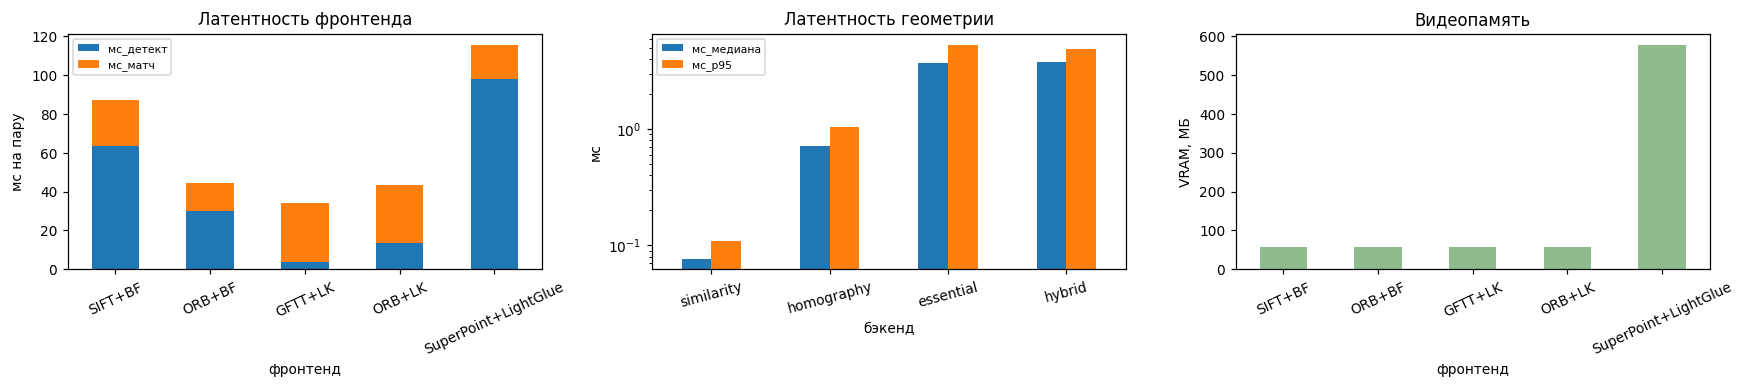

In [21]:
m_ref = FRONTENDS["SIFT+BF"](*pairs[0])

def geom_latency():
    rows = []
    for nm, fn in [("similarity", lambda mm: vc.solve_similarity(mm, GSD, 3.0, agl=AGL)),
                   ("homography", lambda mm: vc.solve_homography(mm, K, 2.0, plane_dist=AGL)),
                   ("essential",  lambda mm: vc.solve_essential(mm, K, 1.0)),
                   ("hybrid",     lambda mm: vc.solve_hybrid(mm, K, GSD, thresh=1.0, agl=AGL))]:
        r = pf.bench_backend(fn, m_ref, warmup=5, runs=40); r["бэкенд"] = nm
        rows.append(r)
    return pd.DataFrame(rows).set_index("бэкенд")

geom = cached("rep_geom_latency.csv", geom_latency, index_col="бэкенд")
display(geom)

fig, ax = plt.subplots(1, 3, figsize=(16, 3.6))
bench[["мс_детект", "мс_матч"]].plot.bar(stacked=True, ax=ax[0])
ax[0].set_ylabel("мс на пару"); ax[0].set_title("Латентность фронтенда")
ax[0].tick_params(axis="x", rotation=25); ax[0].legend(fontsize=7)
geom[["мс_медиана", "мс_p95"]].plot.bar(ax=ax[1], logy=True)
ax[1].set_ylabel("мс"); ax[1].set_title("Латентность геометрии")
ax[1].tick_params(axis="x", rotation=15); ax[1].legend(fontsize=7)
if "VRAM_torch_МБ" in bench.columns:
    bench["VRAM_torch_МБ"].fillna(0).plot.bar(ax=ax[2], color="darkseagreen")
ax[2].set_ylabel("VRAM, МБ"); ax[2].set_title("Видеопамять")
ax[2].tick_params(axis="x", rotation=25)
plt.tight_layout(); plt.show()

### 8.2 Результаты

| фронтенд | мс/пара | p95 | кадр/с | матчей | VRAM |
|---|---|---|---|---|---|
| **GFTT+LK** | **34.4** | 51.5 | 29.1 | 1147 | — |
| ORB+LK | 42.7 | 70.4 | 23.4 | 1676 | — |
| ORB+BF | 45.3 | 59.4 | 22.1 | 261 | — |
| SIFT+BF | 88.3 | 118.5 | 11.4 | 253 | — |
| SuperPoint+LightGlue | 117.3 | 145.8 | 8.6 | 545 | **577 МБ** |

| бэкенд | мс медиана | p95 | max |
|---|---|---|---|
| подобие | 0.077 | 0.110 | 0.151 |
| гомография | 0.712 | 1.04 | 2.67 |
| эссенциальная | 3.73 | 5.35 | 6.17 |
| гибрид | 3.78 | 4.93 | 6.07 |

Наблюдения:

* **Геометрия дешевле фронтенда на 1–3 порядка.** Даже самый дорогой
  бэкенд занимает 3.8 мс против 34–117 мс на сопоставление. Оптимизировать
  надо фронтенд.
* **Время геометрии недетерминировано.** У гомографии максимум превышает
  медиану в 3.7 раза (0.71 → 2.67 мс), у эссенциальной — в 1.7 раза.
  Причина — зависимость числа итераций RANSAC от доли выбросов. Для систем
  с жёстким бюджетом времени это существеннее медианы.
* **SuperPoint+LightGlue дороже всех по всем осям:** в 2.6 раза медленнее
  ORB+BF, 577 МБ видеопамяти против нуля у классических методов. На 6 ГБ
  RTX 2060 это не проблема, но на встраиваемой платформе — ограничение.
* **RSS не различает методы** (≈2.7 ГБ у всех): доминируют кэш кадров
  и загруженные библиотеки, вклад самих детекторов теряется на этом фоне.
  Информативен прирост VRAM, который у классических методов равен нулю.
* **О «реальном времени» говорить некорректно:** последовательность
  передискретизирована по пространству, привязки к времени нет.
  При скорости 50 м/с и базе 55 м требуется около 1 обработки в секунду,
  что с запасом обеспечивают все методы.

---

## 9. Выводы

### 9.1 Сравнение трёх подходов задания

In [22]:
tr, va = res["Train"].set_index(["фронтенд", "бэкенд"]), res["Val"].set_index(["фронтенд", "бэкенд"])
spec = [("(a) SIFT + Essential Matrix", "SIFT+BF", "essential_const"),
        ("(a) ORB + Essential Matrix",  "ORB+BF",  "essential_const"),
        ("(b) GFTT + Lucas-Kanade",     "GFTT+LK", "similarity"),
        ("(b) ORB + Lucas-Kanade",      "ORB+LK",  "similarity")]
if learned is not None:
    spec.append((f"(c) {learned.name}", learned.name, "similarity"))

summary = pd.DataFrame([dict(
    метод=label,
    ATE_Val=va.loc[(fe, be), "ATE_sim3"], дрейф_Val=va.loc[(fe, be), "дрейф_pct"],
    ATE_Train=tr.loc[(fe, be), "ATE_sim3"], дрейф_Train=tr.loc[(fe, be), "дрейф_pct"],
    матчей=tr.loc[(fe, be), "матчей"], inl=tr.loc[(fe, be), "inl"],
    мс_пара=bench.loc[fe, "мс_медиана"], кадр_в_с=bench.loc[fe, "кадр_в_с"],
    VRAM_МБ=bench.loc[fe].get("VRAM_torch_МБ", 0)) for label, fe, be in spec])
display(summary)
summary.to_csv(LOGS / "rep_summary.csv", index=False)

,метод,ATE_Val,дрейф_Val,ATE_Train,дрейф_Train,матчей,inl,мс_пара,кадр_в_с,VRAM_МБ
0,(a) SIFT + Essential Matrix,72.2,1.58,5833.4,20.49,147,0.924,88.3,11.4,58.3
1,(a) ORB + Essential Matrix,79.1,1.73,7296.4,25.63,352,0.806,45.3,22.1,58.3
2,(b) GFTT + Lucas-Kanade,93.5,2.04,2951.8,10.37,519,0.557,34.4,29.1,58.3
3,(b) ORB + Lucas-Kanade,95.0,2.07,1897.0,6.66,1570,0.691,42.7,23.4,58.3
4,(c) SuperPoint+LightGlue,97.4,2.13,1878.7,6.60,508,0.463,117.3,8.6,577.1


### 9.2 Основные результаты

**Геометрия важнее фронтенда.** Разброс точности между пятью способами
сопоставления при фиксированной модели — 5.6 % на насыщенной точками сцене
и 52 % на бедной; между геометрическими моделями — 139–157 %. Оптимизировать
в первую очередь надо не сопоставление.

**Найден и количественно объяснён систематический источник ошибки.**
Модель подобия на наклонной сцене выдумывает поворот величиной
$(t_x n_y - t_y n_x)/2d$; на данных это −0.151 °/шаг. Прогноз, вычисленный
только из GT-ориентации и GT-смещения, воспроизводит 56 % эффекта
при наклоне регрессии 1.03 — то есть механизм описан верно, но существует
второй источник сопоставимой величины. Ошибка курса накапливается линейно
и доминирует в дрейфе.

**Доля инлаеров не отражает качество.** Она монотонно растёт с порогом
RANSAC по построению (0.37 → 0.99), тогда как ошибка траектории на том же
диапазоне меняется немонотонно и всего на 30 %. Устойчивой связи между
ними нет. MAGSAC++ не показал преимущества над обычным RANSAC: основные
ошибки здесь не выбросы сопоставления, а несоответствие модели.

**ORB устойчивее SIFT** на низком разрешении (повторяемость 0.742 против
0.613) и не даёт отказов там, где SIFT отказывает в 7.5 % случаев.
Устойчивость детектора значима не средним значением, а поведением в провалах.

**Обучаемый фронтенд не окупается на этом домене.** SuperPoint+LightGlue
уступает по повторяемости (0.615), в 2.6 раза медленнее ORB+BF и требует
577 МБ видеопамяти. По точности он даёт лучший результат на Train
в связке с подобием (1879 м) и худший на Val (97.4 м) — то есть выигрыша,
оправдывающего цену, нет. Домен обучения (наземные фотографии) далёк
от надирной аэросъёмки сельской местности.

**Универсально лучшего бэкенда нет.** Ранг переворачивается между сплитами:
на насыщенной точками сцене выигрывает эссенциальная матрица, на бедной —
гомография. Выбор модели должен зависеть от условий, а не задаваться заранее.

### 9.3 Ограничения работы

* **Масштаб.** GSD не постоянен вдоль трассы (0.5798 на Val против 0.6134
  на Train), единой константы `plane_dist` не существует. Основная метрика —
  ATE после выравнивания sim(3).
* **Точность калибровки GSD.** Невязка линейной модели составила 21.7 %,
  что связано с включением в выборку коротких баз (stride 10, сдвиг 48 px),
  где относительная погрешность оценки сдвига велика.
* **Фокусное расстояние** по плоской надирной сцене неопределимо в принципе;
  принято значение из геометрии кропа, выводы от него не зависят.
* **Сплит Test** непригоден для одометрии (перемешан, без телеметрии),
  использован только для проверки геометрии кадров.
* **Постоянный шаг** — свойство пространственной передискретизации данного
  датасета, на реальном видео метод потребует внешнего источника масштаба.
* **44 % смещения курса** остались необъяснёнными; кандидаты — дисторсия,
  смещённая главная точка, остаточный рельеф, асимметрия распределения
  точек по кадру.
* **Псевдо-GT для повторяемости** строится по SIFT и смещён в его пользу.
* Оптимизации не применялись: bundle adjustment, ключевые кадры, замыкание
  циклов, фильтрация по IMU. Это чистая покадровая одометрия.

### 9.4 Что дало бы наибольший выигрыш дальше

1. **Скользящее окно / bundle adjustment** — совместная оптимизация
   нескольких кадров снимает значительную часть накопления курса.
2. **Явная оценка нормали плоскости** вместо априорной $(0,0,1)$ —
   напрямую атакует источник смещения из §6.2.
3. **Адаптивный выбор бэкенда** по числу матчей и обусловленности —
   следует из переворота ранга в §7.2.
4. **Абсолютная привязка** к ортофотоплану (для чего датасет исходно
   и создавался) — устраняет накопление принципиально.